In [5]:
import numba
from numba import njit

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

### Question 1

In [7]:
@njit(fastmath = True)
def initialize_lattice(N, state = 'random'):
    """Initializes an N x N lattice with spins +1 or -1."""
    if state == 'up':
        return np.ones((N, N), dtype = np.int32)
    res = np.empty((N, N), dtype=np.int32)
    for i in range(N):
        for j in range(N):
            if np.random.random() < 0.5:
                res[i, j] = -1
            else:
                res[i, j] = 1
    return res

In [8]:
@njit(fastmath = True)
def metropolis_step_efficient(lattice, beta, J = 1.0):
    " implements a single Monte Carlo sweep "
    N = lattice.shape[0]
    total_dE = 0
    for _ in range(N * N):
        i = np.random.randint(0, N) # picks a random site on the grid to test.
        j = np.random.randint(0, N)
        s = lattice[i, j]
        nb = (lattice[(i+1) % N, j] + lattice[(i-1) % N, j] +
              lattice[i, (j+1) % N] + lattice[i, (j-1) % N])
        dE = 2 * J * s * nb
        
        if dE <= 0 or np.random.rand() < np.exp(-beta * dE): # decides if the flip of spin is accepted or not
            "Here the 2nd condition means if dE > 0, then the configuration is accepted with probability exp (-beta * dE)" 
            lattice[i, j] *= -1
            total_dE += dE # Track the change!
    return lattice, total_dE

In [9]:
@njit(fastmath = True)
def calculate_energy(lattice, J = 1.0):
    """Calculates total energy of the lattice."""
    N = lattice.shape[0]
    energy = 0
    for i in range(N):
        for j in range(N):
            s = lattice[i, j]
            # Only look at right and down neighbors to avoid double counting
            nb = lattice[(i+1) % N, j] + lattice[i, (j+1) % N]
            energy -= J * s * nb
    return energy

In [10]:
@njit(fastmath = True)
def simulate_ising(N, T, eq_steps = 5000, mc_steps = 50000, skip = 100, J = 1.0):
    """
    Simulates Ising model for a given size N and temperature T.
    Returns lists of energy and magnetization samples.
    """
    beta = 1.0 / T
    lattice = initialize_lattice(N, state = 'up')
    
    # 1. Equilibration Phase
    for _ in range(eq_steps):
        metropolis_step_efficient(lattice, beta, J)
        
    # 2. Measurement Phase
    current_energy = calculate_energy(lattice, J)
    num_samples = mc_steps // skip
    energies = np.zeros(num_samples)
    magnetizations = np.zeros(num_samples)
    
    sample_idx = 0
    for s in range(mc_steps):
        lattice, dE_step = metropolis_step_efficient(lattice, beta, J)
        current_energy += dE_step
        
        if s % skip == 0 and sample_idx < num_samples:
            energies[sample_idx] = current_energy
            magnetizations[sample_idx] = np.abs(np.sum(lattice))
            sample_idx += 1
            
    return energies, magnetizations

In [7]:
# Execution for the specific lattice sizes
lattice_sizes = [16, 25, 40, 60, 80, 100]
T_target = 2.0  # Around the MFT predicted Tc

for N in lattice_sizes:
    E_samples, M_samples = simulate_ising(N, T_target)
    avg_m = np.mean(M_samples) / (N*N)
    print(f"Lattice {N}x{N} | Avg |M| per site: {avg_m:.4f}")

Lattice 16x16 | Avg |M| per site: 0.9098
Lattice 25x25 | Avg |M| per site: 0.9060
Lattice 40x40 | Avg |M| per site: 0.9097
Lattice 60x60 | Avg |M| per site: 0.9120
Lattice 80x80 | Avg |M| per site: 0.9130
Lattice 100x100 | Avg |M| per site: 0.9122


### Question 2

In [8]:
# Range of temperatures from 0.2 to 4.0
# We use a finer step near the suspected critical point (2.0 to 3.0)
temperatures = np.concatenate([
    np.arange(0.2, 2.0, 0.2), 
    np.arange(2.0, 3.0, 0.1), 
    np.arange(3.0, 4.0, 0.2)
])

lattice_sizes = [16, 25, 40, 60, 80, 100]  

all_results = {}

for N in lattice_sizes:
    print(f"\n--- Starting simulation for N={N} ---")
    
    # Temporary lists for the current N
    current_N_energies = []
    current_N_magnetizations = []
    
    for T in temperatures:
        # Run simulation
        E_samples, M_samples = simulate_ising(N, T, eq_steps = 5000, mc_steps = 50000, skip = 100, J = 1.0)
        
        # Calculate averages and normalize by total number of spins (N*N)
        current_N_energies.append(np.mean(E_samples) / (N * N))
        current_N_magnetizations.append(np.mean(M_samples) / (N * N))
        
        print(f"N: {N} | T: {T:.1f} | <E>: {current_N_energies[-1]:.3f} | <|M|>: {current_N_magnetizations[-1]:.3f}")
    
    # Store the finished lists into our master dictionary before moving to the next N
    all_results[N] = {
        'energy': current_N_energies,
        'magnetization': current_N_magnetizations
    }


--- Starting simulation for N=16 ---
N: 16 | T: 0.2 | <E>: -2.000 | <|M|>: 1.000
N: 16 | T: 0.4 | <E>: -2.000 | <|M|>: 1.000
N: 16 | T: 0.6 | <E>: -2.000 | <|M|>: 1.000
N: 16 | T: 0.8 | <E>: -2.000 | <|M|>: 1.000
N: 16 | T: 1.0 | <E>: -1.997 | <|M|>: 0.999
N: 16 | T: 1.2 | <E>: -1.988 | <|M|>: 0.997
N: 16 | T: 1.4 | <E>: -1.970 | <|M|>: 0.992
N: 16 | T: 1.6 | <E>: -1.929 | <|M|>: 0.980
N: 16 | T: 1.8 | <E>: -1.857 | <|M|>: 0.956
N: 16 | T: 2.0 | <E>: -1.743 | <|M|>: 0.909
N: 16 | T: 2.1 | <E>: -1.662 | <|M|>: 0.868
N: 16 | T: 2.2 | <E>: -1.547 | <|M|>: 0.787
N: 16 | T: 2.3 | <E>: -1.406 | <|M|>: 0.670
N: 16 | T: 2.4 | <E>: -1.253 | <|M|>: 0.515
N: 16 | T: 2.5 | <E>: -1.134 | <|M|>: 0.387
N: 16 | T: 2.6 | <E>: -1.034 | <|M|>: 0.297
N: 16 | T: 2.7 | <E>: -0.978 | <|M|>: 0.244
N: 16 | T: 2.8 | <E>: -0.908 | <|M|>: 0.213
N: 16 | T: 2.9 | <E>: -0.862 | <|M|>: 0.199
N: 16 | T: 3.0 | <E>: -0.822 | <|M|>: 0.172
N: 16 | T: 3.2 | <E>: -0.747 | <|M|>: 0.145
N: 16 | T: 3.4 | <E>: -0.687 | <|M|>: 

### Question 3

In [11]:
def get_distributions(N, T, eq_steps = 5000 , mc_steps = 50000):
    """Collects a large number of samples for histogramming."""
    beta = 1.0 / T
    lattice = initialize_lattice(N, state = 'random') # Random start to avoid bias
    
    # Long equilibration to ensure we aren't seeing starting bias
    for _ in range(eq_steps): 
        metropolis_step_efficient(lattice, beta)
        
    energies = []
    magnetization = []
    current_energy = calculate_energy(lattice)
    
    for s in range(mc_steps):
        lattice, dE = metropolis_step_efficient(lattice, beta)
        current_energy += dE
        
        # Sample frequently for distribution shape,  but skip enough to avoid identical configurations
        if s % 10 == 0:
            energies.append(current_energy / (N*N))
            magnetization.append(np.sum(lattice) / (N*N))
            
    return np.array(energies), np.array(magnetization)

Simulating N=16...
Simulating N=25...
Simulating N=40...
Simulating N=60...
Simulating N=80...
Simulating N=100...


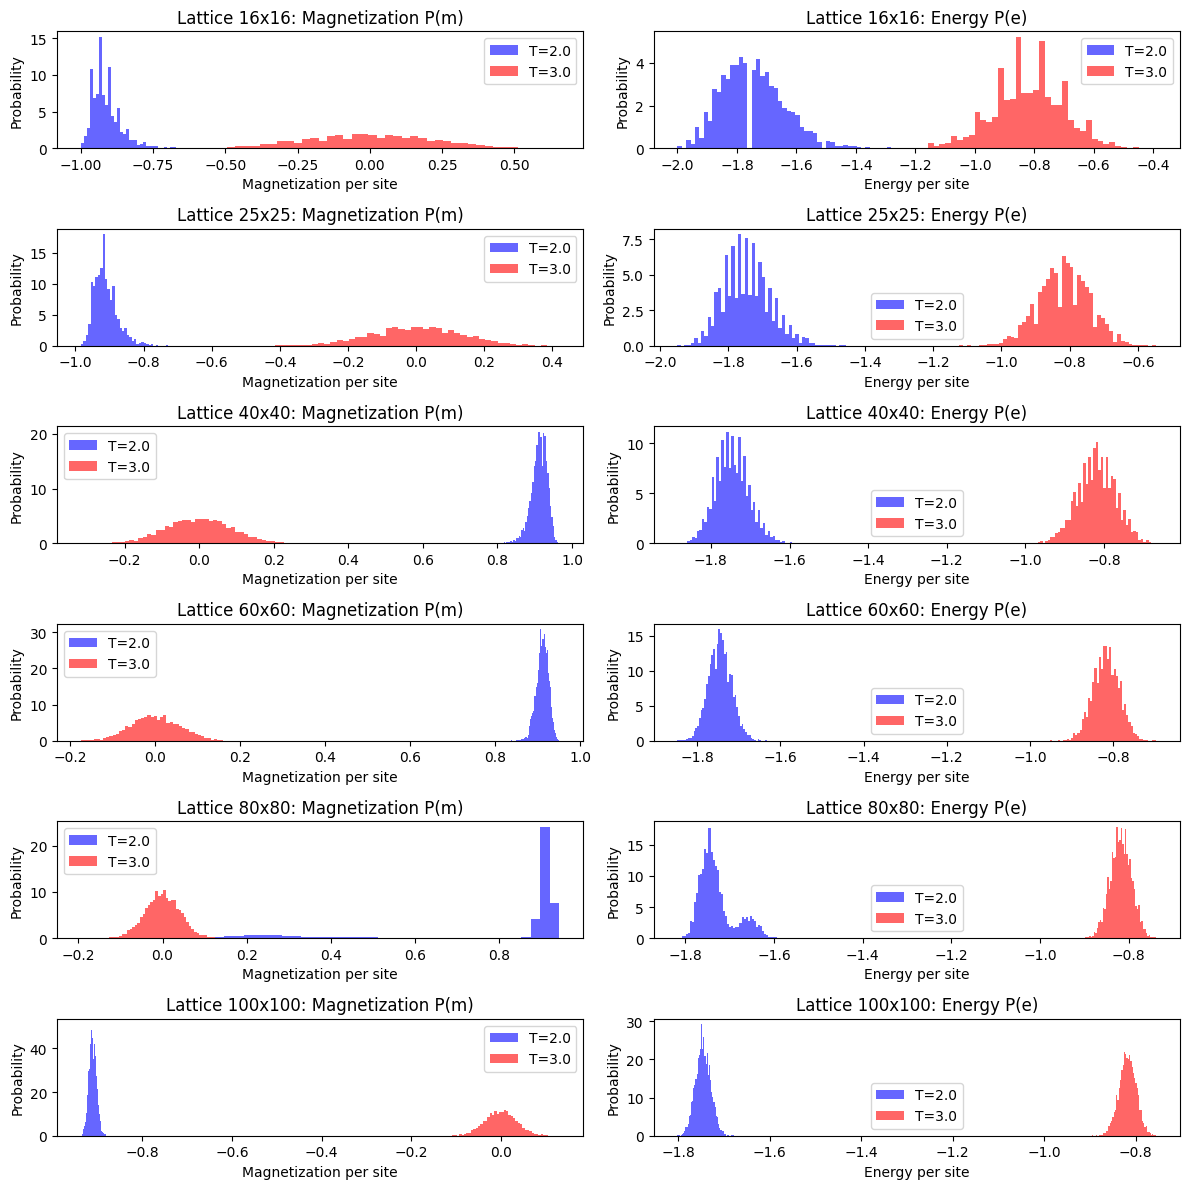

In [12]:
# Configuration
lattice_sizes = [16, 25, 40, 60, 80, 100]
T_low = 2.0
T_high = 3.0
mc_steps = 50000  
skip = 100

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(len(lattice_sizes), 2, figsize=(12, 12))

for i, N in enumerate(lattice_sizes):
    print(f"Simulating N={N}...")
    
    # Run simulations for both temperatures
    E_low, M_low = get_distributions(N, T_low)
    E_high, M_high = get_distributions(N, T_high)
    
    # --- Column 1: Magnetization Distribution ---
    ax_m = axes[i, 0]
    ax_m.hist(M_low, bins=50, alpha=0.6, label=f'T={T_low}', color='blue', density=True)
    ax_m.hist(M_high, bins=50, alpha=0.6, label=f'T={T_high}', color='red', density=True)
    ax_m.set_title(f"Lattice {N}x{N}: Magnetization P(m)")
    ax_m.set_xlabel("Magnetization per site")
    ax_m.set_ylabel("Probability")
    ax_m.legend()

    # --- Column 2: Energy Distribution ---
    ax_e = axes[i, 1]
    ax_e.hist(E_low, bins=50, alpha=0.6, label=f'T={T_low}', color='blue', density=True)
    ax_e.hist(E_high, bins=50, alpha=0.6, label=f'T={T_high}', color='red', density=True)
    ax_e.set_title(f"Lattice {N}x{N}: Energy P(e)")
    ax_e.set_xlabel("Energy per site")
    ax_e.set_ylabel("Probability")
    ax_e.legend()

plt.tight_layout()
plt.show()

Calculating variances for N=16...
Calculating variances for N=25...
Calculating variances for N=40...
Calculating variances for N=60...
Calculating variances for N=80...
Calculating variances for N=100...


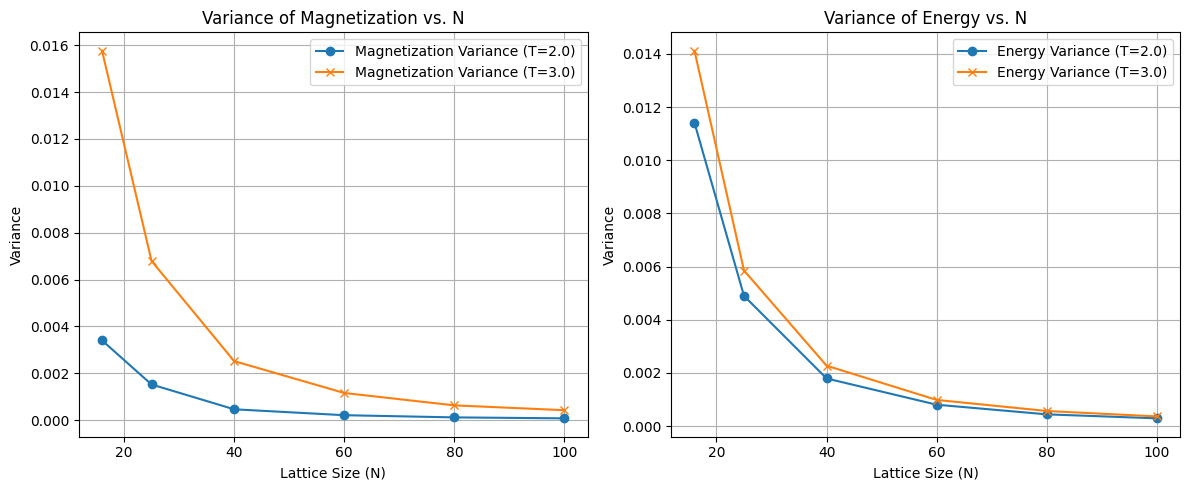

In [13]:
lattice_sizes = [16, 25, 40, 60, 80, 100]
T_low = 2.0
T_high = 3.0
mc_steps = 50000
skip = 100

variances_M_low = []
variances_M_high = []
variances_E_low = []
variances_E_high = []

for N in lattice_sizes:
    print(f"Calculating variances for N={N}...")
    # Re-run simulations to get distributions
    E_low, M_low = get_distributions(N, T_low)
    E_high, M_high = get_distributions(N, T_high)

    # Calculate variances
    variances_M_low.append(np.var(np.abs(M_low)))
    variances_M_high.append(np.var(np.abs(M_high)))
    variances_E_low.append(np.var(E_low))
    variances_E_high.append(np.var(E_high))

# Convert to numpy arrays for easier plotting
variances_M_low = np.array(variances_M_low)
variances_M_high = np.array(variances_M_high)
variances_E_low = np.array(variances_E_low)
variances_E_high = np.array(variances_E_high)

# Plotting the variances vs N
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lattice_sizes, variances_M_low, 'o-', label=f'Magnetization Variance (T={T_low})')
plt.plot(lattice_sizes, variances_M_high, 'x-', label=f'Magnetization Variance (T={T_high})')
plt.xlabel('Lattice Size (N)')
plt.ylabel('Variance')
plt.title('Variance of Magnetization vs. N')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(lattice_sizes, variances_E_low, 'o-', label=f'Energy Variance (T={T_low})')
plt.plot(lattice_sizes, variances_E_high, 'x-', label=f'Energy Variance (T={T_high})')
plt.xlabel('Lattice Size (N)')
plt.ylabel('Variance')
plt.title('Variance of Energy vs. N')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Question 4

In [11]:
def run_simulation_at_T(N, T, eq_steps = 5000, mc_steps = 50000, skip = 100):
    beta = 1.0 / T
    J = 1.0
    lattice = initialize_lattice(N, state = 'up')
    
    # 1. Equilibrate
    for _ in range(eq_steps):
        metropolis_step_efficient(lattice, beta, J)
        
    # 2. Measurement Phase
    current_energy = calculate_energy(lattice, J)
    energies = []
    magnets = []
    
    for s in range(mc_steps):
        lattice, dE_step = metropolis_step_efficient(lattice, beta, J)
        current_energy += dE_step
        
        if s % skip == 0:
            energies.append(current_energy)
            magnets.append(np.sum(lattice))
            
    # Calculate Observables
    E = np.array(energies)
    M = np.abs(np.array(magnets)) # Use |M| for finite systems
    n_sites = N**2
    
    avg_m = np.mean(M) / n_sites
    susceptibility = (np.var(M)) / (n_sites * T)
    specific_heat = (np.var(E)) / (n_sites * T**2)
    
    return avg_m, susceptibility, specific_heat

Simulating N=16...
Simulating N=25...
Simulating N=40...
Simulating N=60...
Simulating N=80...
Simulating N=100...


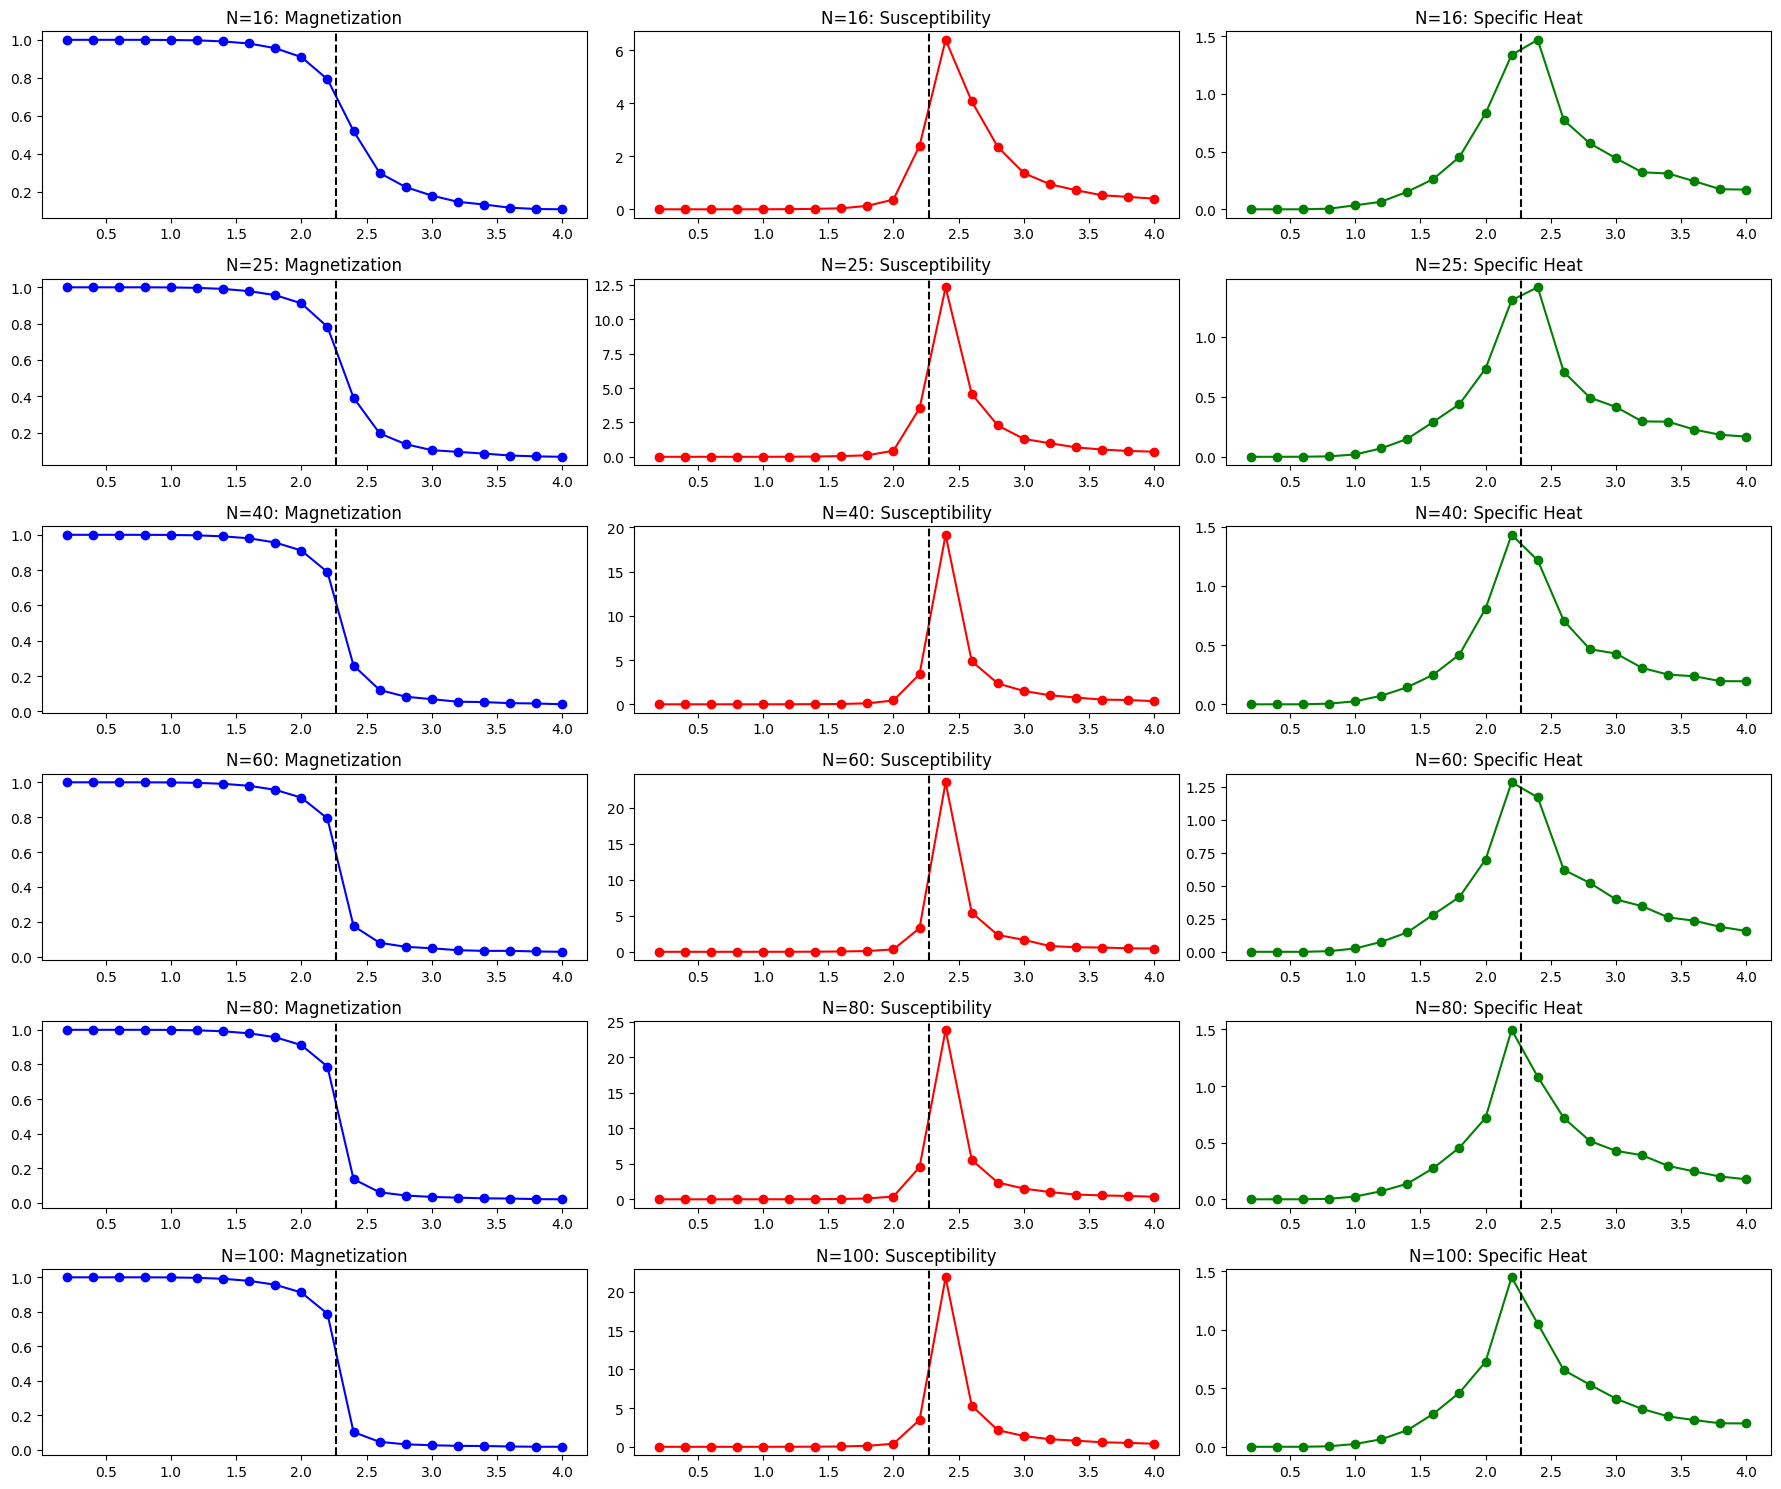

In [13]:
lattice_sizes = [16, 25, 40, 60, 80, 100]
temperatures = np.linspace(0.2, 4.0, 20)

# PERSISTENT STORAGE
M_all_N = []
Chi_all_N = []
Cv_all_N = []

fig, axes = plt.subplots(len(lattice_sizes), 3, figsize=(18, 15))

for i, N in enumerate(lattice_sizes):
    print(f"Simulating N={N}...")
    M_list, Chi_list, Cv_list = [], [], []
    
    for T in temperatures:
        m, chi, cv = run_simulation_at_T(N, T)
        M_list.append(m)
        Chi_list.append(chi)
        Cv_list.append(cv)
    
    # SAVE to our persistent lists
    M_all_N.append(M_list)
    Chi_all_N.append(Chi_list)
    Cv_all_N.append(Cv_list)
    
    # Plotting for this row (i)
    axes[i, 0].plot(temperatures, M_list, 'o-', color='blue')
    axes[i, 0].axvline(x = 2.269, color = 'black', linestyle = '--', label = r'Exact $T_c$')
    axes[i, 0].set_title(f"N={N}: Magnetization")
    
    axes[i, 1].plot(temperatures, Chi_list, 'o-', color='red')
    axes[i, 1].axvline(x = 2.269, color = 'black', linestyle = '--', label = r'Exact $T_c$')
    axes[i, 1].set_title(f"N={N}: Susceptibility")
    
    axes[i, 2].plot(temperatures, Cv_list, 'o-', color='green')
    axes[i, 2].axvline(x = 2.269, color = 'black', linestyle = '--', label = r'Exact $T_c$')
    axes[i, 2].set_title(f"N={N}: Specific Heat")

plt.tight_layout()
plt.show()

### Question 5

In [14]:
Tc = []

for i, N in enumerate(lattice_sizes):
    # Use the data specifically for lattice size N
    current_M = np.array(M_all_N[i])
    current_Chi = np.array(Chi_all_N[i])
    current_Cv = np.array(Cv_all_N[i])
    
    # Find numerical Tc for THIS specific N
    idx_max = np.argmax(current_Chi)
    Tc.append(temperatures[idx_max])

Tc = np.array(Tc)

In [15]:
# Storage for the filtered points of each lattice size
filtered_data = {}

for i, N in enumerate(lattice_sizes):
    # 1. Get the specific Tc for this N from your Tc array
    current_tc = Tc[i]
    
    # 2. Get the specific Susceptibility list for this N
    current_chi_list = np.array(Chi_all_N[i])
    
    # 3. Define masks relative to this specific Tc
    # We use a window (e.g., 1.0) to capture the critical region
    mask_above = (temperatures > current_tc) & (temperatures < current_tc + 1.0)
    mask_below = (temperatures > current_tc - 1.0) & (temperatures < current_tc)
    
    # 4. Extract the points
    T_pts_above = temperatures[mask_above]
    Chi_pts_above = current_chi_list[mask_above]
    
    T_pts_below = temperatures[mask_below]
    Chi_pts_below = current_chi_list[mask_below]
    
    # Store in a dictionary for easy access later (e.g., for plotting or regression)
    filtered_data[N] = {
        'T_above': T_pts_above,
        'Chi_above': Chi_pts_above,
        'T_below': T_pts_below,
        'Chi_below': Chi_pts_below,
        'Tc_used': current_tc
    }
    
    # Quick print to verify we caught enough points
    print(f"N={N} (Tc={current_tc:.3f}): Found {len(T_pts_above)} pts above, {len(T_pts_below)} pts below.")

N=16 (Tc=2.400): Found 4 pts above, 4 pts below.
N=25 (Tc=2.400): Found 4 pts above, 4 pts below.
N=40 (Tc=2.400): Found 4 pts above, 4 pts below.
N=60 (Tc=2.400): Found 4 pts above, 4 pts below.
N=80 (Tc=2.400): Found 4 pts above, 4 pts below.
N=100 (Tc=2.400): Found 4 pts above, 4 pts below.


In [16]:
# Dictionary to store calculated exponents for each N
gamma_results = {}

for i, N in enumerate(lattice_sizes):
    # 1. Get the specific Tc and filtered points for this lattice size
    # Assuming filtered_data was populated in the previous step
    data = filtered_data[N]
    current_tc = data['Tc_used']
    
    T_above = data['T_above']
    Chi_above = data['Chi_above']
    T_below = data['T_below']
    Chi_below = data['Chi_below']

    # 2. Calculate reduced temperatures t = |T - Tc| / Tc
    t_above = np.abs((T_above - current_tc) / current_tc)
    t_below = np.abs((T_below - current_tc) / current_tc)

    # 3. Filter zeros and perform Log-Log Regression for 'Above'
    valid_a = t_above > 0
    if np.any(valid_a):
        log_t_a = np.log(t_above[valid_a])
        log_chi_a = np.log(Chi_above[valid_a])
        res_a = linregress(log_t_a, log_chi_a)
        gamma_a = -res_a.slope
    else:
        gamma_a = np.nan

    # 4. Filter zeros and perform Log-Log Regression for 'Below'
    valid_b = t_below > 0
    if np.any(valid_b):
        log_t_b = np.log(t_below[valid_b])
        log_chi_b = np.log(Chi_below[valid_b])
        res_b = linregress(log_t_b, log_chi_b)
        gamma_b = -res_b.slope
    else:
        gamma_b = np.nan

    # Store results
    gamma_results[N] = {'gamma_above': gamma_a, 'gamma_below': gamma_b}

    print(f"--- Lattice N = {N} (Tc = {current_tc:.3f}) ---")
    print(f"Calculated Gamma from above: {gamma_a:.4f}")
    print(f"Calculated Gamma from below: {gamma_b:.4f}\n")

--- Lattice N = 16 (Tc = 2.400) ---
Calculated Gamma from above: 1.0522
Calculated Gamma from below: 2.9158

--- Lattice N = 25 (Tc = 2.400) ---
Calculated Gamma from above: 1.1253
Calculated Gamma from below: 3.0822

--- Lattice N = 40 (Tc = 2.400) ---
Calculated Gamma from above: 1.1139
Calculated Gamma from below: 3.2124

--- Lattice N = 60 (Tc = 2.400) ---
Calculated Gamma from above: 1.3018
Calculated Gamma from below: 3.0967

--- Lattice N = 80 (Tc = 2.400) ---
Calculated Gamma from above: 1.2127
Calculated Gamma from below: 3.3210

--- Lattice N = 100 (Tc = 2.400) ---
Calculated Gamma from above: 1.2126
Calculated Gamma from below: 3.0723



In [17]:
beta_results = {}

for i, N in enumerate(lattice_sizes):
    # 1. Get the numerical Tc for this specific N
    current_tc = Tc[i]
    
    # 2. Get the specific Magnetization list for this N
    current_m_list = np.array(M_all_N[i])
    
    # 3. Mask points below Tc (ordered phase)
    # Using a window of 1.0
    mask_beta = (temperatures < current_tc) & (temperatures > current_tc - 1.0)
    
    # 4. Calculate reduced temperature t for valid points
    t_beta = np.abs((temperatures[mask_beta] - current_tc) / current_tc)
    m_pts = current_m_list[mask_beta]
    
    # 5. Filter out zeros to avoid log errors
    valid = (t_beta > 0) & (m_pts > 0)
    log_t = np.log(t_beta[valid])
    log_m = np.log(m_pts[valid])
    
    # 6. Linear Regression: ln(m) = beta * ln|t| + C
    # The slope is directly the exponent beta
    res = linregress(log_t, log_m)
    beta_calc = res.slope
    
    beta_results[N] = beta_calc
    
    print(f"Lattice N={N} (Tc={current_tc:.3f}) | Calculated Beta: {beta_calc:.4f}")

Lattice N=16 (Tc=2.400) | Calculated Beta: 0.1562
Lattice N=25 (Tc=2.400) | Calculated Beta: 0.1646
Lattice N=40 (Tc=2.400) | Calculated Beta: 0.1589
Lattice N=60 (Tc=2.400) | Calculated Beta: 0.1556
Lattice N=80 (Tc=2.400) | Calculated Beta: 0.1601
Lattice N=100 (Tc=2.400) | Calculated Beta: 0.1588


In [18]:
# Dictionary to store results for each lattice size
alpha_results = {}

for i, N in enumerate(lattice_sizes):
    # Get the specific Tc for this lattice size
    current_tc = Tc[i] 
    
    # Get the specific Cv list for this lattice size
    # Assuming Cv_all_N is the list of lists containing the 20 samples for each N
    current_cv_list = np.array(Cv_all_N[i])

    # Now the shapes match: (20,) < scalar
    mask_alpha_below = (temperatures < current_tc) & (temperatures > current_tc - 1.0)

    # Calculate reduced temperature using the scalar Tc
    t_alpha_below = np.abs((temperatures[mask_alpha_below] - current_tc) / current_tc)
    cv_pts_below = current_cv_list[mask_alpha_below]

    # Filter out zeros to avoid log(0)
    v_b = t_alpha_below > 0
    if np.any(v_b):
        log_t = np.log(t_alpha_below[v_b])
        log_cv = np.log(cv_pts_below[v_b])

        # Linear Regression
        slope, intercept, r_val, p_val, std_err = linregress(log_t, log_cv)
        alpha_calc = -slope
        
        alpha_results[N] = alpha_calc
        print(f"Lattice N={N} (Tc={current_tc:.3f}) | Calculated Alpha: {alpha_calc:.4f}")
    else:
        print(f"Lattice N={N}: No valid points found in the mask window.")

Lattice N=16 (Tc=2.400) | Calculated Alpha: 1.1479
Lattice N=25 (Tc=2.400) | Calculated Alpha: 1.0704
Lattice N=40 (Tc=2.400) | Calculated Alpha: 1.2428
Lattice N=60 (Tc=2.400) | Calculated Alpha: 1.0879
Lattice N=80 (Tc=2.400) | Calculated Alpha: 1.1887
Lattice N=100 (Tc=2.400) | Calculated Alpha: 1.1497


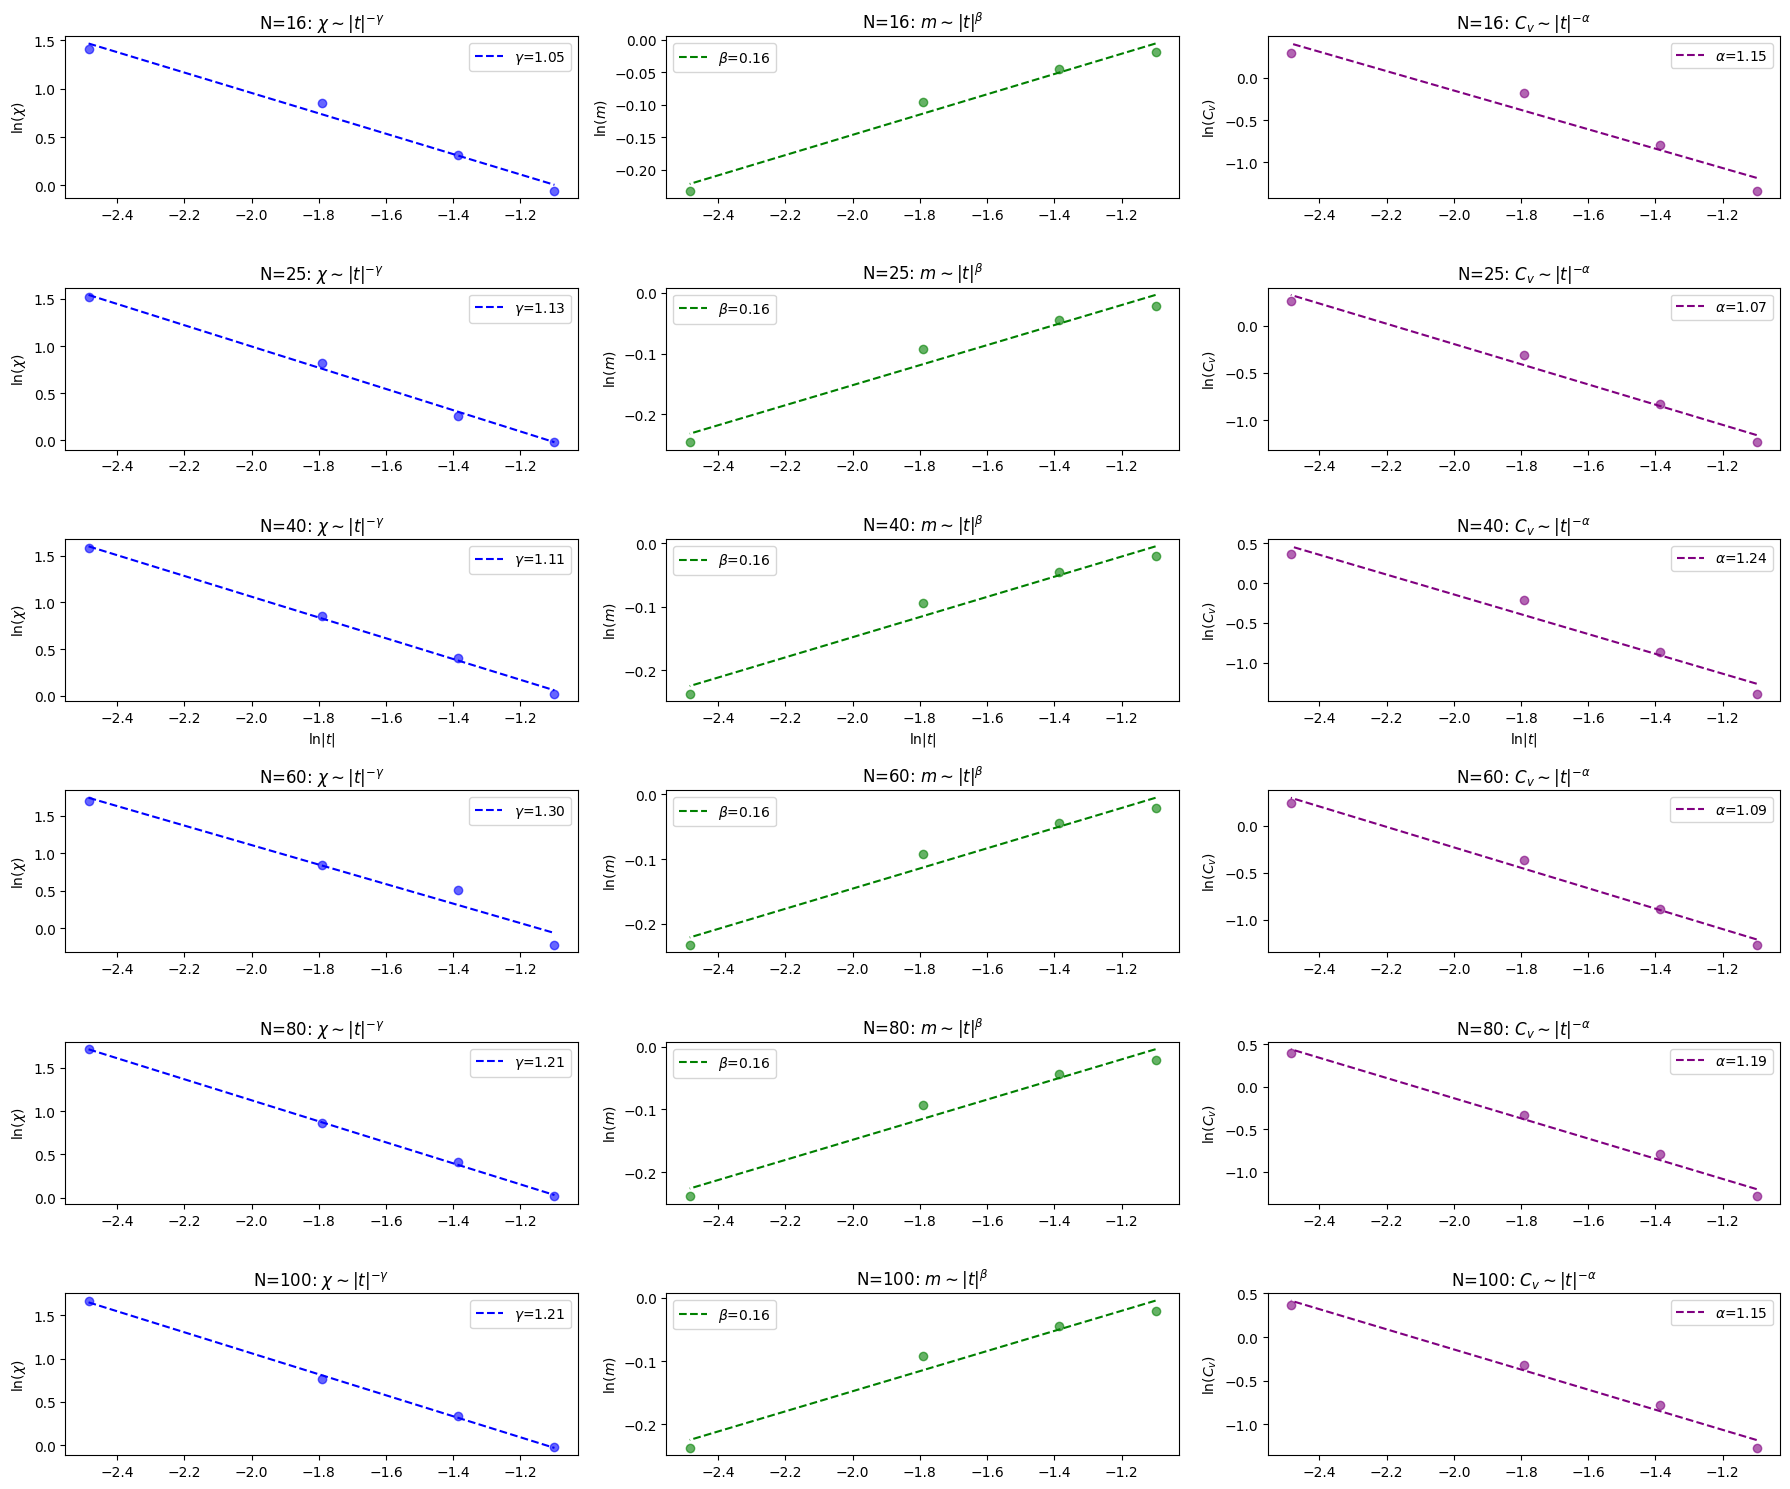

In [19]:
# Create a 3x3 grid (Rows: Lattice Size, Columns: Property)
fig, axes = plt.subplots(len(lattice_sizes), 3, figsize=(18, 15))

for i, N in enumerate(lattice_sizes):
    # --- Retrieve values from previous steps ---
    current_tc = Tc[i]
    
    # 1. Gamma Data (Susceptibility - Below Tc)
    # Using the logic from the previous step for filtered_data[N]
    data_g = filtered_data[N] # Assuming this dictionary was created
    t_g = np.abs((data_g['T_above'] - current_tc) / current_tc)
    valid_g = t_g > 0
    log_t_g = np.log(t_g[valid_g])
    log_chi = np.log(data_g['Chi_above'][valid_g])
    slope_g, inter_g, r_g, _, _ = linregress(log_t_g, log_chi)
    
    # 2. Beta Data (Magnetization - Below Tc)
    m_data = np.array(M_all_N[i])
    mask_b = (temperatures < current_tc) & (temperatures > current_tc - 1.0)
    t_b = np.abs((temperatures[mask_b] - current_tc) / current_tc)
    m_pts = m_data[mask_b]
    valid_b = (t_b > 0) & (m_pts > 0)
    log_t_b = np.log(t_b[valid_b])
    log_m = np.log(m_pts[valid_b])
    slope_b, inter_b, r_b, _, _ = linregress(log_t_b, log_m)
    
    # 3. Alpha Data (Specific Heat - Below Tc)
    cv_data = np.array(Cv_all_N[i])
    mask_a = (temperatures < current_tc) & (temperatures > current_tc - 1.0)
    t_a = np.abs((temperatures[mask_a] - current_tc) / current_tc)
    cv_pts = cv_data[mask_a]
    valid_a = (t_a > 0) & (cv_pts > 0)
    log_t_a = np.log(t_a[valid_a])
    log_cv = np.log(cv_pts[valid_a])
    slope_a, inter_a, r_a, _, _ = linregress(log_t_a, log_cv)

    # --- Plotting Column 1: Gamma ---
    ax0 = axes[i, 0]
    ax0.scatter(log_t_g, log_chi, color='blue', alpha=0.6)
    ax0.plot(log_t_g, slope_g * log_t_g + inter_g, 'b--', label=f'$\\gamma$={-slope_g:.2f}')
    ax0.set_title(f'N={N}: $\\chi \\sim |t|^{{-\\gamma}}$')
    ax0.set_ylabel(r'$\ln(\chi)$')
    ax0.legend()

    # --- Plotting Column 2: Beta ---
    ax1 = axes[i, 1]
    ax1.scatter(log_t_b, log_m, color='green', alpha=0.6)
    ax1.plot(log_t_b, slope_b * log_t_b + inter_b, 'g--', label=f'$\\beta$={slope_b:.2f}')
    ax1.set_title(f'N={N}: $m \\sim |t|^{{\\beta}}$')
    ax1.set_ylabel(r'$\ln(m)$')
    ax1.legend()

    # --- Plotting Column 3: Alpha ---
    ax2 = axes[i, 2]
    ax2.scatter(log_t_a, log_cv, color='purple', alpha=0.6)
    ax2.plot(log_t_a, slope_a * log_t_a + inter_a, color='purple', linestyle='--', label=f'$\\alpha$={-slope_a:.2f}')
    ax2.set_title(f'N={N}: $C_v \\sim |t|^{{-\\alpha}}$')
    ax2.set_ylabel(r'$\ln(C_v)$')
    ax2.legend()

# Shared X-label for the bottom row
for ax in axes[2, :]:
    ax.set_xlabel(r'$\ln|t|$')

plt.tight_layout()
plt.show()

In [20]:
def calculate_correlation_function(lattice):
    N = lattice.shape[0]
    max_r = N // 2
    G = np.zeros(max_r)
    
    # Calculated average <Si>
    avg_s = np.mean(lattice)
    
    # We iterate over distances r
    for r in range(max_r):
        # Calculated <Si * Si+r> averaged over the whole lattice
        # We check correlations in both x and y directions for better statistics
        corr_x = np.mean(lattice * np.roll(lattice, -r, axis = 1))
        corr_y = np.mean(lattice * np.roll(lattice, -r, axis = 0))
        
        G[r] = (corr_x + corr_y) / 2.0 - avg_s**2
        
    return G

In [21]:
lattice_sizes = [16, 25, 40, 60, 80, 100]
results_G = {}

for i, N in enumerate(lattice_sizes):
    print(f"Calculating Correlation Function for N={N}...")
    
    # Using the specific Tc for this lattice size
    current_tc = Tc[i] 
    current_beta = 1.0 / current_tc
    
    lattice = initialize_lattice(N, state='up')
    
    # 1. Long equilibration
    for _ in range(1000): 
        metropolis_step_efficient(lattice, current_beta)

    # 2. Measurement Phase
    all_G = []
    for s in range(5000):
        lattice, _ = metropolis_step_efficient(lattice, current_beta)
        if s % 100 == 0:
            # This function returns an array of length N // 2
            all_G.append(calculate_correlation_function(lattice))

    # 3. Average and store
    avg_G = np.mean(all_G, axis=0)
    r_values = np.arange(len(avg_G))
    
    results_G[N] = (r_values, avg_G)

Calculating Correlation Function for N=16...
Calculating Correlation Function for N=25...
Calculating Correlation Function for N=40...
Calculating Correlation Function for N=60...
Calculating Correlation Function for N=80...
Calculating Correlation Function for N=100...


In [22]:
# Dictionary to store calculated eta for each N
eta_results = {}

for i, N in enumerate(lattice_sizes):
    # Retrieve r and G for this lattice size
    r_values, avg_G = results_G[N]
    
    # 1. Ensure G only contains positive values for the log
    mask = avg_G > 0
    r_valid = r_values[mask]
    G_valid = avg_G[mask]

    # 2. Focus on r >= 1 and r <= N/4 to avoid self-correlation and boundary noise
    # For N=16, this is r=[1, 2, 3, 4]. For N=40, this is r=[1...10]
    fit_mask = (r_valid >= 1) & (r_valid <= N // 4)
    r_final = r_valid[fit_mask]
    G_final = G_valid[fit_mask]

    if len(r_final) >= 2:
        log_r = np.log(r_final)
        log_G = np.log(G_final)
        
        # 3. Linear Regression: ln(G) = -eta * ln(r) + C
        slope_eta, intercept, r_val, _, _ = linregress(log_r, log_G)
        calc_eta = -slope_eta
        eta_results[N] = calc_eta
        
        print(f"Lattice N={N} | Calculated Eta: {calc_eta:.4f}")
    else:
        print(f"Lattice N={N}: Not enough points in fit range.")

Lattice N=16 | Calculated Eta: 1.4333
Lattice N=25 | Calculated Eta: 1.2848
Lattice N=40 | Calculated Eta: 1.1742
Lattice N=60 | Calculated Eta: 1.3338
Lattice N=80 | Calculated Eta: 1.2726
Lattice N=100 | Calculated Eta: 1.6089


### Question 6

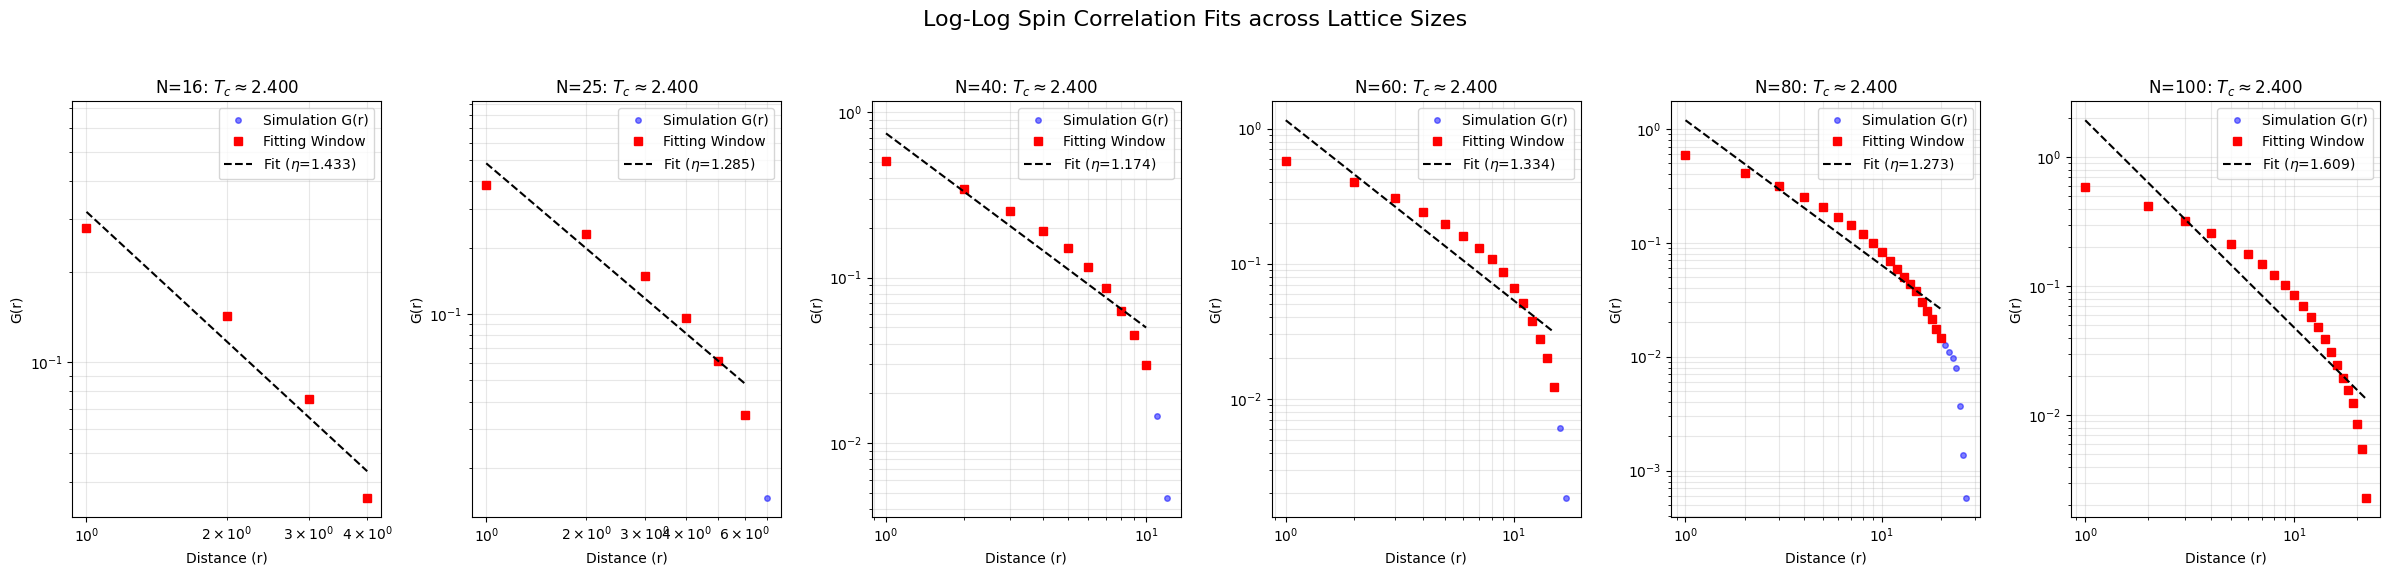

In [26]:
fig, axes = plt.subplots(1, len(lattice_sizes), figsize=(24, 6))

for i, N in enumerate(lattice_sizes):
    ax = axes[i]
    
    # 1. Retrieve the specific data and Tc for this N
    r_values, avg_G = results_G[N]
    current_tc = Tc[i]
    
    # 2. Filter positive values for log-log plotting
    mask_pos = avg_G > 0
    r_valid = r_values[mask_pos]
    G_valid = avg_G[mask_pos]
    
    # 3. Define the fitting window (r=1 to N/4)
    fit_mask = (r_valid >= 1) & (r_valid <= N // 4)
    r_final = r_valid[fit_mask]
    G_final = G_valid[fit_mask]
    
    if len(r_final) >= 2:
        # 4. Performing the linear regression in log-log space
        slope, intercept, r_val, _, _ = linregress(np.log(r_final), np.log(G_final))
        calc_eta = -slope
        
        # --- Plotting ---
        # Plotting all positive points (Simulation Data)
        ax.loglog(r_valid, G_valid, 'ob', markersize=4, label='Simulation G(r)', alpha=0.5)
        
        # Highlighting the points used for the fit
        ax.loglog(r_final, G_final, 'sr', markersize=6, label='Fitting Window')
        
        # Generating and plotting the fit line: G = exp(intercept) * r^(slope)
        fit_line = np.exp(intercept) * r_final**(slope)
        ax.loglog(r_final, fit_line, 'k--', label=rf'Fit ($\eta$={calc_eta:.3f})')
        
        # Formatting
        ax.set_title(fr"N={N}: $T_c \approx {current_tc:.3f}$")
        ax.set_xlabel("Distance (r)")
        ax.set_ylabel("G(r)")
        ax.legend()
        ax.grid(True, which="both", ls="-", alpha=0.3)
    else:
        ax.set_title(fr"N={N}: $T_c \approx {current_tc:.3f}$")

plt.suptitle("Log-Log Spin Correlation Fits across Lattice Sizes", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()